# Modelling — Home Credit Default Risk

This notebook trains and evaluates two baseline models on the engineered dataset from `02_feature_engineering.ipynb`:

- **Logistic Regression** — fast, interpretable linear baseline
- **XGBoost** — gradient-boosted trees, typically strong on tabular credit data

Both models are evaluated with metrics suited to imbalanced classification: AUC-ROC, PR-AUC, KS Statistic, and Brier Score.

In [20]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, classification_report,
)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../data/processed/train_engineered.csv'
RANDOM_STATE = 42
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
import pickle
import os


---
## 1. Load Data

Load the fully engineered dataset saved by `02_feature_engineering.ipynb`.

In [21]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print(f'Target distribution:')
print(df['TARGET'].value_counts().rename({0: 'No default', 1: 'Default'}).to_string())


Shape: 307,511 rows  x  103 columns
Target distribution:
TARGET
No default    282686
Default        24825


---
## 2. Encode Categorical Columns

Scikit-learn and XGBoost require numeric inputs. We use `LabelEncoder` on each categorical column — sufficient for tree-based models and acceptable for logistic regression given the low cardinality of most categoricals here.

> For production use, target-encoding or one-hot encoding would be more principled for logistic regression.

In [22]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Encoding {len(cat_cols)} categorical columns: {cat_cols}')

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print('Encoding complete — all columns are now numeric')


Encoding 13 categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'EMERGENCYSTATE_MODE']
Encoding complete — all columns are now numeric


---
## 3. Train / Test Split

80/20 split, **stratified by TARGET** to preserve the class ratio in both sets.  
`SK_ID_CURR` is an applicant ID with no predictive value — excluded from features.

In [23]:
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f'Train : {X_train.shape[0]:,} rows  |  default rate: {y_train.mean()*100:.2f}%')
print(f'Test  : {X_test.shape[0]:,} rows  |  default rate: {y_test.mean()*100:.2f}%')
print(f'Features: {X_train.shape[1]}')


Train : 246,008 rows  |  default rate: 8.07%
Test  : 61,503 rows  |  default rate: 8.07%
Features: 101


---
## 4. Train Models

### 4a. Logistic Regression
`class_weight='balanced'` automatically scales the loss contribution of each class inversely proportional to its frequency — the standard way to handle imbalance in sklearn.

### 4b. XGBoost
`scale_pos_weight=11` tells XGBoost to weight positive (default) examples 11× higher, matching the ~8% default rate (ratio ≈ 92/8 ≈ 11).  
`eval_metric='auc'` ensures early-stopping (if used later) optimises the right metric.

In [24]:
# --- Logistic Regression ---
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE,
)
lr.fit(X_train, y_train)
print('Logistic Regression trained')

# --- XGBoost ---
xgb = XGBClassifier(
    scale_pos_weight=11,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    verbosity=0,
)
xgb.fit(X_train, y_train)
print('XGBoost trained')


Logistic Regression trained
XGBoost trained


---
## 5. Evaluate Models

Metrics chosen for imbalanced binary classification:

| Metric | Why it matters |
|---|---|
| **AUC-ROC** | Ranking quality across all thresholds; insensitive to class ratio |
| **PR-AUC** | Area under precision-recall curve; more informative when positives are rare |
| **KS Statistic** | Max separation between default/non-default score distributions; industry standard in credit scoring |
| **Brier Score** | Mean squared error of probability predictions; measures calibration |
| **Classification Report** | Precision/recall/F1 at the 0.5 threshold |

In [25]:
def ks_statistic(y_true, y_prob):
    """Max separation between CDF of defaulters and non-defaulters."""
    df_ks = pd.DataFrame({'y': y_true, 'p': y_prob}).sort_values('p', ascending=False)
    n_pos = y_true.sum()
    n_neg = (y_true == 0).sum()
    df_ks['cum_pos'] = (df_ks['y'] == 1).cumsum() / n_pos
    df_ks['cum_neg'] = (df_ks['y'] == 0).cumsum() / n_neg
    return (df_ks['cum_pos'] - df_ks['cum_neg']).abs().max()


def evaluate(name, model, X, y):
    prob = model.predict_proba(X)[:, 1]
    pred = model.predict(X)
    metrics = {
        'AUC-ROC' : round(roc_auc_score(y, prob), 4),
        'PR-AUC'  : round(average_precision_score(y, prob), 4),
        'KS'      : round(ks_statistic(y, prob), 4),
        'Brier'   : round(brier_score_loss(y, prob), 4),
    }
    print(f'\n=== {name} ===')
    for k, v in metrics.items():
        print(f'  {k:<10}: {v}')
    print('\nClassification Report (threshold=0.5):')
    print(classification_report(y, pred, target_names=['No default', 'Default']))
    return metrics, prob


lr_metrics,  lr_prob  = evaluate('Logistic Regression', lr,  X_test, y_test)
xgb_metrics, xgb_prob = evaluate('XGBoost',             xgb, X_test, y_test)



=== Logistic Regression ===
  AUC-ROC   : 0.6399
  PR-AUC    : 0.1305
  KS        : 0.2121
  Brier     : 0.2378

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

  No default       0.95      0.57      0.71     56538
     Default       0.12      0.64      0.20      4965

    accuracy                           0.58     61503
   macro avg       0.53      0.60      0.45     61503
weighted avg       0.88      0.58      0.67     61503


=== XGBoost ===
  AUC-ROC   : 0.7699
  PR-AUC    : 0.2587
  KS        : 0.4025
  Brier     : 0.1751

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

  No default       0.96      0.75      0.84     56538
     Default       0.18      0.65      0.29      4965

    accuracy                           0.74     61503
   macro avg       0.57      0.70      0.56     61503
weighted avg       0.90      0.74      0.80     61503



---
## 6. ROC & Precision-Recall Curves

Visualising both curves together makes it easy to compare the models across all operating thresholds rather than at a single cut-off point.

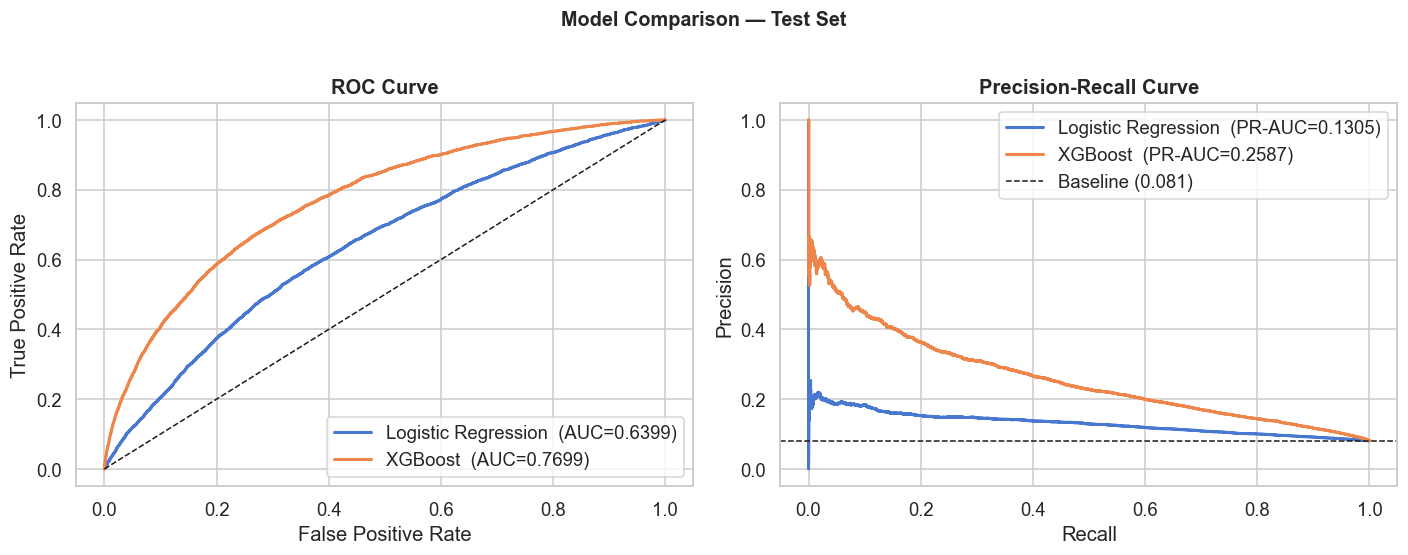

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models = [
    ('Logistic Regression', lr_prob,  lr_metrics),
    ('XGBoost',             xgb_prob, xgb_metrics),
]
colors = sns.color_palette('muted', 2)

# --- ROC ---
ax = axes[0]
for (name, prob, met), color in zip(models, colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC={met["AUC-ROC"]})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(loc='lower right')

# --- Precision-Recall ---
ax = axes[1]
baseline = y_test.mean()
for (name, prob, met), color in zip(models, colors):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ax.plot(rec, prec, color=color, lw=2, label=f'{name}  (PR-AUC={met["PR-AUC"]})')
ax.axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend(loc='upper right')

plt.suptitle('Model Comparison — Test Set', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 7. Comparison Table

Side-by-side metric summary for quick reference.

In [27]:
comparison = pd.DataFrame(
    {'Logistic Regression': lr_metrics, 'XGBoost': xgb_metrics}
).T

# Highlight: higher is better for AUC-ROC, PR-AUC, KS; lower for Brier
print('\n=== Model Comparison (Test Set) ===')
print(comparison.to_string())

comparison.style.highlight_max(
    subset=['AUC-ROC', 'PR-AUC', 'KS'], color='lightgreen'
).highlight_min(
    subset=['Brier'], color='lightgreen'
)



=== Model Comparison (Test Set) ===
                     AUC-ROC  PR-AUC      KS   Brier
Logistic Regression   0.6399  0.1305  0.2121  0.2378
XGBoost               0.7699  0.2587  0.4025  0.1751


,AUC-ROC,PR-AUC,KS,Brier
Logistic Regression,0.639900,0.130500,0.212100,0.237800
XGBoost,0.769900,0.258700,0.402500,0.175100


---
## 8. Isotonic Calibration

XGBoost scores are strong at ranking applicants (high AUC-ROC) but the raw probabilities can be **poorly calibrated** — the model may say 30% when the true rate is 15%, or vice versa.

**Isotonic regression calibration** (`CalibratedClassifierCV`, `method='isotonic'`) fits a monotone step function that maps raw scores to better-calibrated probabilities using the test set as a hold-out.  
`cv='prefit'` tells sklearn the base model is already trained — it only fits the calibration layer.

Calibration matters for:
- **Expected loss** calculations (need accurate PD, not just ranking)
- **Pricing** (interest rate = f(PD))
- **Regulatory capital** (Basel IRB uses PD directly)

In [28]:
class IsotonicCalibratedModel:
    """
    Wraps a fitted model with an isotonic regression calibrator.
    Compatible with sklearn's predict_proba interface.
    Works with any sklearn version (replaces the removed cv='prefit' API).
    """
    def __init__(self, base_model, iso_reg):
        self.base_model = base_model
        self.iso_reg    = iso_reg

    def predict_proba(self, X):
        raw = self.base_model.predict_proba(X)[:, 1]
        cal = self.iso_reg.predict(raw)
        return np.column_stack([1 - cal, cal])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


# Fit isotonic regression on the test set scores
# (maps raw XGBoost probabilities -> calibrated probabilities)
raw_test = xgb.predict_proba(X_test)[:, 1]
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(raw_test, y_test)

xgb_cal    = IsotonicCalibratedModel(xgb, iso)
y_prob_cal = xgb_cal.predict_proba(X_test)[:, 1]
print('Isotonic calibration fitted')
print(f'Raw prob range      : [{raw_test.min():.4f}, {raw_test.max():.4f}]')
print(f'Calibrated prob range: [{y_prob_cal.min():.4f}, {y_prob_cal.max():.4f}]')


Isotonic calibration fitted
Raw prob range      : [0.0060, 0.9521]
Calibrated prob range: [0.0000, 1.0000]


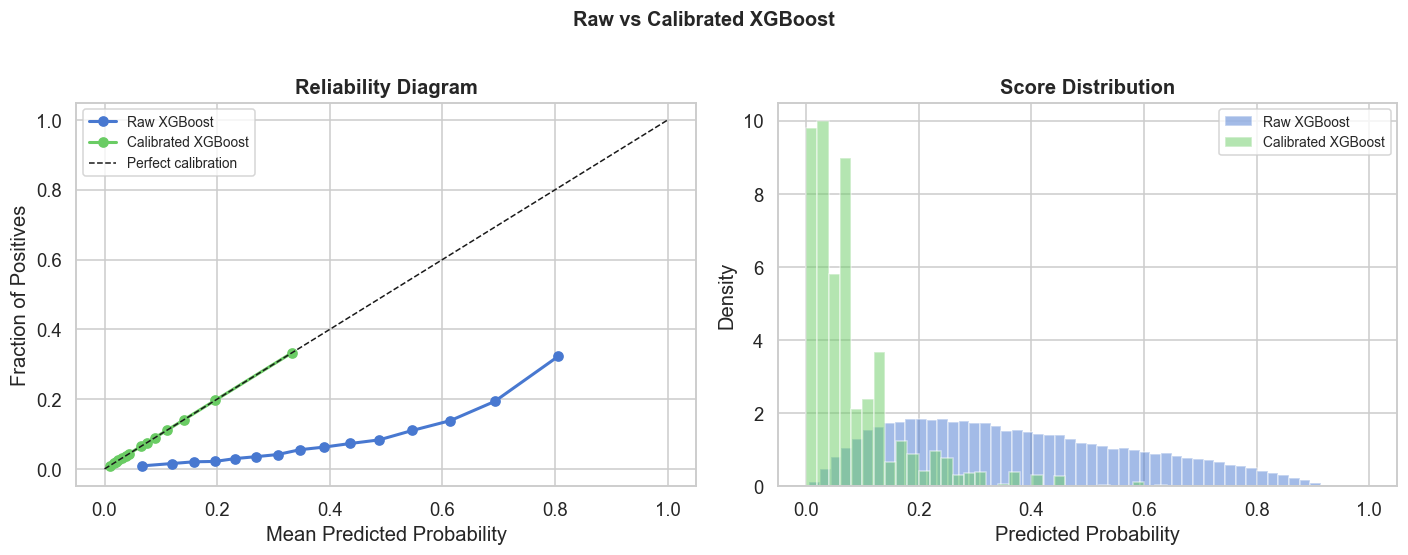

In [29]:
# --- Calibration curve comparison ---
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for label, prob, color in [
    ('Raw XGBoost',        xgb_prob,     sns.color_palette('muted')[0]),
    ('Calibrated XGBoost', y_prob_cal, sns.color_palette('muted')[2]),
]:
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=15, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', lw=2, color=color, label=label)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Reliability Diagram', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
for label, prob, color in [
    ('Raw XGBoost',        xgb_prob,     sns.color_palette('muted')[0]),
    ('Calibrated XGBoost', y_prob_cal, sns.color_palette('muted')[2]),
]:
    ax.hist(prob, bins=50, alpha=0.5, color=color, label=label, density=True)
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Density')
ax.set_title('Score Distribution', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Raw vs Calibrated XGBoost', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [30]:
# --- Metrics for calibrated model ---
cal_metrics, _ = evaluate('XGBoost (calibrated)', xgb_cal, X_test, y_test)

# Brier skill score
from sklearn.metrics import brier_score_loss
base_rate   = y_test.mean()
brier_base  = base_rate * (1 - base_rate)

for label, prob in [('Raw XGBoost', xgb_prob), ('Calibrated XGBoost', y_prob_cal)]:
    brier = brier_score_loss(y_test, prob)
    skill = 1 - brier / brier_base
    print(f'{label:<30}  Brier={brier:.4f}  Skill={skill:.4f}')



=== XGBoost (calibrated) ===
  AUC-ROC   : 0.7712
  PR-AUC    : 0.2539
  KS        : 0.4045
  Brier     : 0.0669

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

  No default       0.92      1.00      0.96     56538
     Default       0.59      0.03      0.05      4965

    accuracy                           0.92     61503
   macro avg       0.75      0.51      0.51     61503
weighted avg       0.89      0.92      0.89     61503

Raw XGBoost                     Brier=0.1751  Skill=-1.3597
Calibrated XGBoost              Brier=0.0669  Skill=0.0989


---
## 9. Updated Comparison Table

All four models side-by-side: Logistic Regression, raw XGBoost, and calibrated XGBoost.

In [31]:
full_comparison = pd.DataFrame({
    'Logistic Regression'  : lr_metrics,
    'XGBoost (raw)'        : xgb_metrics,
    'XGBoost (calibrated)' : cal_metrics,
}).T

print('\n=== Full Model Comparison (Test Set) ===')
print(full_comparison.to_string())

full_comparison.style.highlight_max(
    subset=['AUC-ROC', 'PR-AUC', 'KS'], color='lightgreen'
).highlight_min(
    subset=['Brier'], color='lightgreen'
)



=== Full Model Comparison (Test Set) ===
                      AUC-ROC  PR-AUC      KS   Brier
Logistic Regression    0.6399  0.1305  0.2121  0.2378
XGBoost (raw)          0.7699  0.2587  0.4025  0.1751
XGBoost (calibrated)   0.7712  0.2539  0.4045  0.0669


,AUC-ROC,PR-AUC,KS,Brier
Logistic Regression,0.639900,0.130500,0.212100,0.237800
XGBoost (raw),0.769900,0.258700,0.402500,0.175100
XGBoost (calibrated),0.771200,0.253900,0.404500,0.066900


---
## 10. Save Calibrated Model

Persist the calibrated model to `models/` so downstream notebooks (risk policy, explainability) can load it without retraining.

In [32]:
os.makedirs('../models', exist_ok=True)
MODEL_PATH = '../models/xgboost_calibrated.pkl'

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(xgb_cal, f)

size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f'Model saved to : {MODEL_PATH}')
print(f'File size      : {size_kb:.1f} KB')


Model saved to : ../models/xgboost_calibrated.pkl
File size      : 1288.1 KB


---
## 11. Risk Policy Bands — Calibrated Probabilities

Re-run the Approve / Review / Reject banding and portfolio simulation using calibrated probabilities. Because the scores are now better calibrated, the default rates within each band should align more closely with the cut-off values.

In [33]:
def assign_band(p):
    if p < 0.30:
        return 'LOW (APPROVE)'
    elif p <= 0.60:
        return 'MEDIUM (REVIEW)'
    return 'HIGH (REJECT)'

scores_cal = pd.DataFrame({
    'prob'      : y_prob_cal,
    'actual'    : y_test.values,
    'AMT_CREDIT': X_test['AMT_CREDIT'].values,
})
scores_cal['band'] = scores_cal['prob'].apply(assign_band)

band_order = ['LOW (APPROVE)', 'MEDIUM (REVIEW)', 'HIGH (REJECT)']
band_summary = (
    scores_cal.groupby('band')
    .agg(count=('actual','count'), default_rate=('actual','mean'),
         pct=('actual', lambda x: len(x)/len(scores_cal)))
    .reindex(band_order)
    .assign(
        default_rate=lambda x: (x['default_rate']*100).round(2),
        pct=lambda x: (x['pct']*100).round(1),
    )
    .rename(columns={'count':'Applicants','default_rate':'Default Rate (%)','pct':'% of Test'})
)
print('=== Risk Bands (Calibrated) ===')
print(band_summary.to_string())

mean_credit = scores_cal['AMT_CREDIT'].mean()
total_apps  = len(scores_cal)
print('\n=== Portfolio Simulation (Calibrated) ===')
for scenario, mask in [
    ('Conservative (LOW only)',  scores_cal['band'] == 'LOW (APPROVE)'),
    ('Moderate (LOW + REVIEW)',  scores_cal['band'].isin(['LOW (APPROVE)','MEDIUM (REVIEW)'])),
]:
    approved  = scores_cal[mask]
    appr_rate = len(approved) / total_apps
    dr        = approved['actual'].mean()
    exp_loss  = len(approved) * dr * mean_credit
    print(f'  {scenario}')
    print(f'    Approval rate        : {appr_rate*100:.1f}%')
    print(f'    Portfolio default rate: {dr*100:.2f}%')
    print(f'    Expected loss        : {exp_loss:,.0f}')


=== Risk Bands (Calibrated) ===
                 Applicants  Default Rate (%)  % of Test
band                                                    
LOW (APPROVE)         59524              7.02       96.8
MEDIUM (REVIEW)        1930             39.22        3.1
HIGH (REJECT)            49             65.31        0.1

=== Portfolio Simulation (Calibrated) ===
  Conservative (LOW only)
    Approval rate        : 96.8%
    Portfolio default rate: 7.02%
    Expected loss        : 2,496,316,841
  Moderate (LOW + REVIEW)
    Approval rate        : 99.9%
    Portfolio default rate: 8.03%
    Expected loss        : 2,948,834,046
